In [ ]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

_repo = Path.cwd()
while _repo != _repo.parent and not (_repo / "pyproject.toml").exists():
    _repo = _repo.parent
sys.path.insert(0, str(_repo))

from demos.ControlledPendulum.src.master_pendulum.components import (
    FMUPendulum, OpenSimPendulum, FEMPendulum
)
from demos.ControlledPendulum.scripts.torque_profiles import (
    constant_torque, ramp_torque, zero_torque
)

from demos.ControlledPendulum.src.master_pendulum import MasterPendulum
import demos.ControlledPendulum.src.master_pendulum.components.fem.pendulum_config as config

from syssimx import Connection, System, FMUComponent
from syssimx.system.connection import EventConnection
from syssimx.viz.system_graph_visualizer import SystemGraphVisualizer

In [ ]:
mesh_params = config.MeshParameters()

init_params = config.InitialConditionParameters()
init_params.angular_position_deg = np.rad2deg(0.3) # Initial angle
q0 = np.deg2rad(init_params.angular_position_deg)
init_params.drive_torque = 0 # Nm

mat_params = config.MaterialParameters()
mat_params.E_pendulum = 2.1e11  # Young's modulus for the pendulum
mat_params.nu_pendulum = 0.3    # Poisson's ratio for the pendulum
mat_params.rho_pendulum = 7800  # Density for the pendulum

sim_params = config.SimulationParameters()
sim_params.tau = 0.01
sim_params.t_end = 1.5
sim_params.with_contact = True
sim_params.use_gravity = True

contact_params = config.ContactParameters()
contact_params.kn = 1e9

anim_params = config.AnimationParameters()
anim_params.animate = False

fem_parameters = {
    'mat_params': mat_params,
    'contact_params': contact_params,
    'init_params': init_params,
    'sim_params': sim_params,
    'anim_params': anim_params,
    'mesh_params': mesh_params,
}

pendulum = MasterPendulum(name="MasterPendulum", initial_mode="FMU")

pendulum.set_parameters(**{"FEM": fem_parameters})
pendulum.initialize(t0=0.0)

t = 0.0
dt = pendulum.fem.sim_params.tau
t_end = pendulum.fem.sim_params.t_end

**Monolithic Reference Solution - Modelica**

In [ ]:
# from OMPython import ModelicaSystem

# # 1) Build the Modelica Model
# pkg_dir_path = Path.cwd() / "demos/ControlledPendulum/src/modelica/ControlledPendulum/"
# pkg_file_path = pkg_dir_path / "package.mo"
# model = "ControlledPendulum.PendulumWithWall"

# # 2) Create Modelica System Model
# model = ModelicaSystem(str(pkg_file_path), model)

# # 3) Set Model Parameters
# parameters = [
#     f"pendulum.L={pendulum.fem._equivalent_length}",
#     f"pendulum.m={pendulum.fem.mass}",
#     f"pendulum.inertia={pendulum.fem.inertia}",
#     f"pendulum.q0={q0}",
#     f"wall.c={0}",
#     f"wall.k={contact_params.kn}",
# ]
# model.setParameters(parameters)

# # 4) Set simulation options
# t0 = 0.0
# dt_monolithic = 1e-4
# solver_tolerance = 1e-8
# solver_monolithic = "dassl"
# simulation_options = [
#     f"startTime={t0}",
#     f"stopTime={t_end}",
#     f"stepSize={dt_monolithic}",
#     f"tolerance={solver_tolerance}",
#     f"solver={solver_monolithic}",
# ]
# model.setSimulationOptions(simulation_options)

# # 5) Build model
# model.buildModel()

# # 6) Run simulation
# model.simulate()

# # 7) Retrieve results
# ref_monolithic = {}
# keys = ("time", "pendulum.q", "pendulum.omega", "pendulum.alpha")
# for key in keys:
#     print("Extracting: ", key)
#     ref_monolithic[key] = model.getSolutions(key)
#     ref_monolithic[key] = ref_monolithic[key].flatten()

# t_an_m_vals = ref_monolithic["time"]
# q_an_m_vals = ref_monolithic["pendulum.q"]
# omega_an_m_vals = ref_monolithic["pendulum.omega"]
# alpha_an_m_vals = ref_monolithic["pendulum.alpha"]

**FMU Reference Solution**

In [ ]:
fmu_pendulum_wall_path = Path.cwd() / "demos/ControlledPendulum/artifacts/fmus/PendulumWithWall.fmu"
fmu_pendulum_wall = FMUComponent(name="FMU_Pendulum_Wall", fmu_path=fmu_pendulum_wall_path)

parameters = {
    "pendulum.L": pendulum.fem._equivalent_length,
    "pendulum.m": pendulum.fem.mass,
    "pendulum.inertia": pendulum.fem.inertia,
    "pendulum.q0": q0,
    "wall.c": 0,
    "wall.k": contact_params.kn,
}

fmu_pendulum_wall.set_parameters(**parameters)

t = 0.0
fmu_pendulum_wall.initialize(t)

dt_an = 1e-4
for _ in range(int(t_end / dt_an)):
    fmu_pendulum_wall.do_step(t=t, dt=dt_an)
    t += dt_an

ref_sol_hist = fmu_pendulum_wall.get_history()
t_an_fmu_vals = ref_sol_hist["q"]["time"]
q_an__fmu_vals = ref_sol_hist["q"]["values"]
omega_an_fmu_vals = ref_sol_hist["omega"]["values"]
alpha_an_fmu_vals = ref_sol_hist["alpha"]["values"]

In [ ]:
pendulum.setup_monitoring()
pendulum.display_monitoring()

In [7]:
t = 0.0
while t < t_end:
    # 1) Integrate one time step
    pendulum.do_step(t, dt)

    # 2) Advance time
    t += dt

In [14]:
t_vals = {mode: [] for mode in pendulum.models.keys()}
torque_vals = {mode: [] for mode in pendulum.models.keys()}
alpha_vals = {mode: [] for mode in pendulum.models.keys()}
omega_vals = {mode: [] for mode in pendulum.models.keys()}
q_vals = {mode: [] for mode in pendulum.models.keys()}

for mode in pendulum.models.keys():
    t_vals[mode], res_dict = pendulum.models[mode].get_history_arrays()
    alpha_vals[mode] = res_dict["alpha"]
    omega_vals[mode] = res_dict["omega"]
    q_vals[mode] = res_dict["theta"]

In [10]:
marker_size = 3
fem_style = {
    "color": "#063ccf",
    "linestyle": "None",
    "marker": "o",
    "markersize": marker_size,
    "linewidth": 3.5,
    "label": "FEM",
}
opensim_style = {
    "color": "#f8c20f",
    "linestyle": "None",
    "marker": "s",
    "markersize": marker_size,
    "linewidth": 3.5,
    "label": "OpenSim",
}  # Green
eqb_style = {
    "color": "#24aa09",
    "linestyle": "None",
    "marker": "^",
    "markersize": marker_size,
    "linewidth": 3.5,
    "label": "EQB",
}  # Purple
fontdict = {"fontsize": 11, "fontweight": "bold"}

fig_size = (9, 9)
y_suptitle = 1.04
y_subtitle = 1
y_legend = 0.99
top_adjust = 0.9

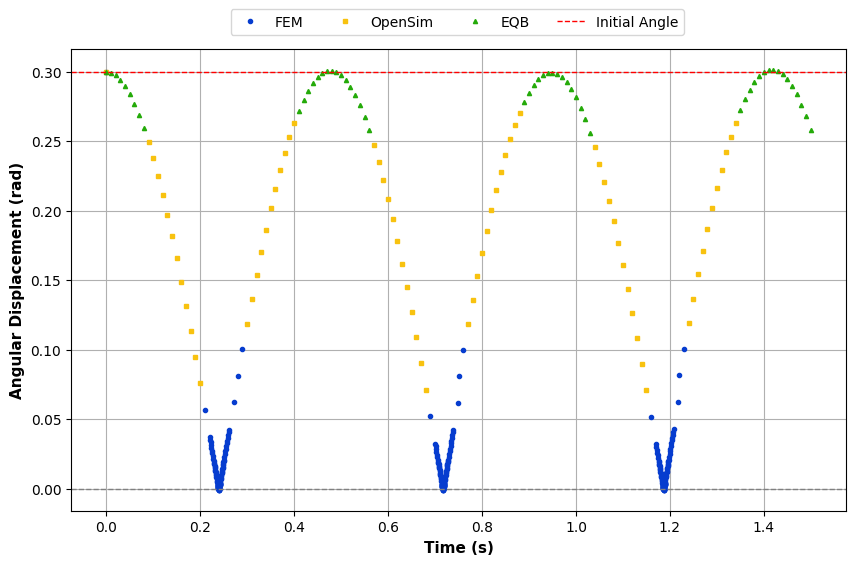

In [26]:
plt.figure(figsize=(10, 6))
plt.plot(t_vals["FEM"], q_vals["FEM"], **fem_style)
plt.plot(t_vals["OpenSim"], q_vals["OpenSim"], **opensim_style)
plt.plot(t_vals["FMU"], q_vals["FMU"], **eqb_style)
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.axhline(q0, color="red", linestyle="--", linewidth=1, label="Initial Angle")
plt.xlabel("Time (s)", fontdict=fontdict)
plt.ylabel("Angular Displacement (rad)", fontdict=fontdict)
plt.legend(bbox_to_anchor=(0.8, 1.1), ncol=4, fontsize=10)
plt.grid()